# Intro

**Seminar by @Elad_Benjo**

In this notebook I will attempt to develop a new model for nowcsating of the Israeli GDP.

Our efforts would be towards a DFM, since we have various frequencies and high demensional data.

In [ ]:
from google.colab import drive
import sys
import pandas as pd

drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/gdp_nowcasting_seminar/src')

Mounted at /content/drive


## Papers

https://www.federalreserve.gov/econres/ifdp/files/ifdp1385.pdf

https://research-api.cbs.dk/ws/portalfiles/portal/108037712/1790388_Masters_thesis_final.pdf

https://unit8co.github.io/darts/generated_api/darts.dataprocessing.transformers.midas.html

https://www.bankofengland.co.uk/macro-technical-paper/2025/nowcasting-gdp-at-the-bank-of-england-a-staggered-combination-midas-approach

https://www.bundesbank.de/resource/blob/703478/e103f573e8ad3241e7cd65431dcbaf6c/mL/2009-03-20-dkp-07-data.pdf

https://research-api.cbs.dk/ws/portalfiles/portal/108037712/1790388_Masters_thesis_final.pdf

# OLS

## full daily+monthly df

In [ ]:
factor_df = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/factor_df.pkl')

In [ ]:
factor_quarterly = factor_df.rolling(30).mean().resample("QE").last()

In [ ]:
from statsmodels.api import OLS, add_constant


X = add_constant(factor_quarterly)
y = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/y_train.pkl')


In [ ]:
y = y['GDP']

In [ ]:
X = X.loc[y.index]

In [ ]:
model = OLS(y, X, missing="drop").fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                   0.02022
Date:                Sun, 31 Aug 2025   Prob (F-statistic):              0.887
Time:                        23:45:17   Log-Likelihood:                 293.91
No. Observations:                 107   AIC:                            -583.8
Df Residuals:                     105   BIC:                            -578.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0098      0.002      6.463      0.0

## monthly df

In [193]:
df = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/factor_df_k4_p2_covdiagonal.pkl')

In [194]:
df.head()

,factor
Date,
1995-01-01,0.025354
1995-02-01,0.052684
1995-03-01,-0.114279
1995-04-01,0.069790
1995-05-01,-0.221711


In [195]:
df_quarterly_end = df.resample("QE").last()

In [196]:
df_quarterly_end.head()

,factor
Date,
1995-03-31,-0.114279
1995-06-30,0.116273
1995-09-30,0.210311
1995-12-31,-0.165206
1996-03-31,-0.442987


In [197]:
from statsmodels.api import OLS, add_constant


X = add_constant(df_quarterly_end)
y = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/y_train.pkl')

In [198]:
y = y['GDP']

In [199]:
y.head()

,GDP
Date,
1995-06-30,0.020498
1995-09-30,0.011781
1995-12-31,0.006393
1996-03-31,0.011674
1996-06-30,0.018468


In [200]:
X = X.loc[y.index]

In [201]:
X.head()

,const,factor
Date,,
1995-06-30,1.0,0.116273
1995-09-30,1.0,0.210311
1995-12-31,1.0,-0.165206
1996-03-31,1.0,-0.442987
1996-06-30,1.0,0.393617


In [202]:
model = OLS(y, X, missing="drop").fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     5.064
Date:                Sat, 06 Sep 2025   Prob (F-statistic):             0.0265
Time:                        21:17:36   Log-Likelihood:                 296.42
No. Observations:                 107   AIC:                            -588.8
Df Residuals:                     105   BIC:                            -583.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0100      0.001      6.756      0.0

In [203]:
y_pred = model.predict(X)

In [204]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# y = true values (from your quarterly series)
# y_pred = predicted values from the model

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.6f}")

RMSE: 0.015159
MAE:  0.009326
R²:   0.046009


# ARIMA

In [206]:
y = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/y_train.pkl')

In [208]:
y = y['GDP']

In [191]:
X = df_quarterly_end.loc[y.index]

In [210]:
X = X['factor']

In [211]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(y, X)
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    GDP   No. Observations:                  107
Model:                          ARIMA   Log Likelihood                 296.417
Date:                Sat, 06 Sep 2025   AIC                           -586.834
Time:                        21:19:33   BIC                           -578.816
Sample:                    06-30-1995   HQIC                          -583.584
                         - 12-31-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0100      0.002      4.931      0.000       0.006       0.014
factor         0.0025      0.001      3.916      0.000       0.001       0.004
sigma2         0.0002    1.5e-05     15.363      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)


In [212]:
y_pred = model_fit.predict()

In [213]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# y = true values (from your quarterly series)
# y_pred = predicted values from the model

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.6f}")

RMSE: 0.015159
MAE:  0.009325
R²:   0.046008


# MIDAS Almon

## first attempt

In [ ]:
sys.path.append('/content/drive/MyDrive/gdp_nowcasting_seminar/src/models')

In [ ]:
gdp_series = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/y_train.pkl')['GDP']

In [ ]:
gdp_series.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 107 entries, 1995-06-30 to 2021-12-31
Series name: GDP
Non-Null Count  Dtype  
--------------  -----  
107 non-null    float64
dtypes: float64(1)
memory usage: 1.7 KB


In [ ]:
# Shift each date to the 16th of the next month
gdp_series.index = (
    gdp_series.index + pd.offsets.MonthBegin(1)  # move to first of next month
).normalize() + pd.Timedelta(days=15)  # then add 15 days to get to the 16th

In [ ]:
gdp_series.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 107 entries, 1995-07-16 to 2022-01-16
Series name: GDP
Non-Null Count  Dtype  
--------------  -----  
107 non-null    float64
dtypes: float64(1)
memory usage: 1.7 KB


In [ ]:
gdp_series.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/y_train_midas.pkl')

In [ ]:
factor_df = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/factor_df.pkl')

In [ ]:
factor_seires = factor_df["factor"]

In [ ]:
factor_series.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9876 entries, 1995-01-03 to 2022-01-16
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   factor  9876 non-null   float64
dtypes: float64(1)
memory usage: 412.4 KB


In [ ]:
import models

In [ ]:
X = models.build_high_freq_lags(factor_series, gdp_series.index, 15)

In [ ]:
y = gdp_series.values

In [ ]:
import midas_almon

In [ ]:
print(X.shape)

(107, 35, 1)


In [ ]:
X = X.squeeze(axis=2)  # removes the singleton third dimension
print(X.shape)  # should now be (107, 106)

(107, 15)


### train

In [ ]:
# Create the model
model = midas_almon.AlmonMIDASRegressor(degree=2)  # Polynomial of degree 2

# Fit the model
model.fit(y, X)

# Predict (on training data or new test data)
y_pred = model.predict(X)

### predict

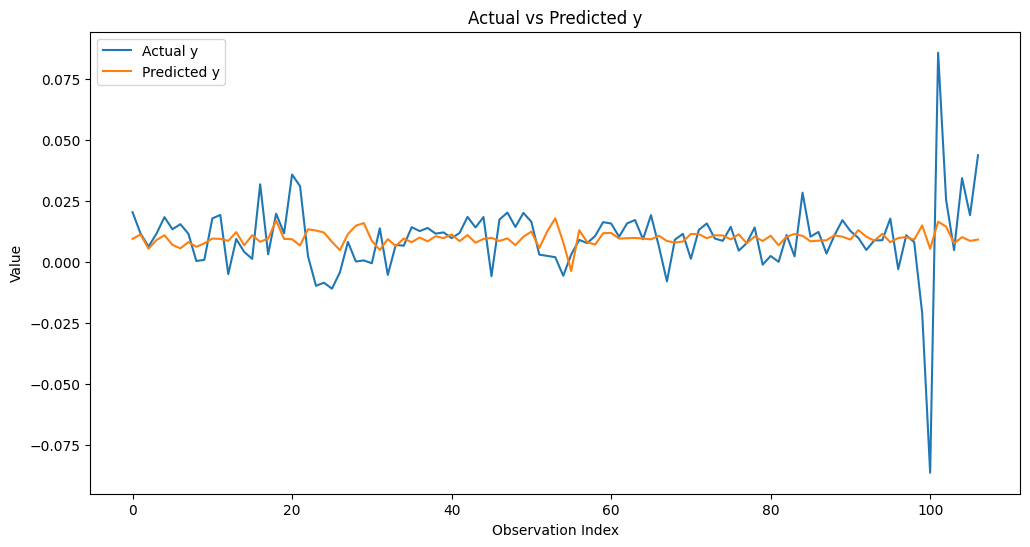

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y, label='Actual y')
plt.plot(y_pred, label='Predicted y')
plt.title('Actual vs Predicted y')
plt.xlabel('Observation Index')
plt.ylabel('Value')
plt.legend()
plt.show()

In [ ]:
y_pred

array([0.00986022, 0.00959111, 0.00985955, 0.00965156, 0.00957337,
       0.00981391, 0.01008963, 0.00947782, 0.00971792, 0.00987123,
       0.00962335, 0.01008709, 0.00983342, 0.00964004, 0.00984756,
       0.01001247, 0.00976588, 0.00970434, 0.00985722, 0.00956165,
       0.01001706, 0.0092584 , 0.01015618, 0.00971776, 0.00995852,
       0.00969926, 0.01009935, 0.00961801, 0.0099085 , 0.00971553,
       0.00985573, 0.01025488, 0.00938519, 0.01006442, 0.00974604,
       0.0098537 , 0.00974359, 0.0099166 , 0.00979185, 0.0096201 ,
       0.00983324, 0.00986226, 0.00977664, 0.00988096, 0.00940935,
       0.01026134, 0.00954726, 0.00986802, 0.00928752, 0.01009601,
       0.00936708, 0.01008007, 0.00933512, 0.009314  , 0.0104626 ,
       0.01073837, 0.00914326, 0.00993182, 0.00980061, 0.00962038,
       0.01002231, 0.01019458, 0.00972518, 0.00977254, 0.00978357,
       0.00983373, 0.0098403 , 0.0096939 , 0.00984382, 0.00964283,
       0.00976502, 0.00982462, 0.00976797, 0.00990334, 0.00996

In [ ]:
print("Almon weights:", model.get_lag_weights())


Almon weights: [ 1.93729077e-04  1.90555552e-04  1.87382028e-04  1.84208503e-04
  1.81034978e-04  1.77861454e-04  1.74687929e-04  1.71514405e-04
  1.68340880e-04  1.65167356e-04  1.61993831e-04  1.58820307e-04
  1.55646782e-04  1.52473258e-04  1.49299733e-04  1.46126209e-04
  1.42952684e-04  1.39779160e-04  1.36605635e-04  1.33432111e-04
  1.30258586e-04  1.27085062e-04  1.23911537e-04  1.20738013e-04
  1.17564488e-04  1.14390964e-04  1.11217439e-04  1.08043915e-04
  1.04870390e-04  1.01696865e-04  9.85233410e-05  9.53498164e-05
  9.21762919e-05  8.90027674e-05  8.58292429e-05  8.26557184e-05
  7.94821938e-05  7.63086693e-05  7.31351448e-05  6.99616203e-05
  6.67880958e-05  6.36145712e-05  6.04410467e-05  5.72675222e-05
  5.40939977e-05  5.09204732e-05  4.77469486e-05  4.45734241e-05
  4.13998996e-05  3.82263751e-05  3.50528506e-05  3.18793260e-05
  2.87058015e-05  2.55322770e-05  2.23587525e-05  1.91852280e-05
  1.60117034e-05  1.28381789e-05  9.66465439e-06  6.49112987e-06
  3.317605

In [ ]:
w = model.get_lag_weights()
print("Weights:", w)


Weights: [-1.29281516e-04 -1.27243134e-04 -1.25204752e-04 -1.23166370e-04
 -1.21127988e-04 -1.19089606e-04 -1.17051225e-04 -1.15012843e-04
 -1.12974461e-04 -1.10936079e-04 -1.08897697e-04 -1.06859315e-04
 -1.04820933e-04 -1.02782552e-04 -1.00744170e-04 -9.87057879e-05
 -9.66674060e-05 -9.46290242e-05 -9.25906423e-05 -9.05522605e-05
 -8.85138786e-05 -8.64754968e-05 -8.44371149e-05 -8.23987331e-05
 -8.03603512e-05 -7.83219694e-05 -7.62835875e-05 -7.42452056e-05
 -7.22068238e-05 -7.01684419e-05 -6.81300601e-05 -6.60916782e-05
 -6.40532964e-05 -6.20149145e-05 -5.99765327e-05 -5.79381508e-05
 -5.58997690e-05 -5.38613871e-05 -5.18230053e-05 -4.97846234e-05
 -4.77462416e-05 -4.57078597e-05 -4.36694778e-05 -4.16310960e-05
 -3.95927141e-05 -3.75543323e-05 -3.55159504e-05 -3.34775686e-05
 -3.14391867e-05 -2.94008049e-05 -2.73624230e-05 -2.53240412e-05
 -2.32856593e-05 -2.12472775e-05 -1.92088956e-05 -1.71705137e-05
 -1.51321319e-05 -1.30937500e-05 -1.10553682e-05 -9.01698633e-06
 -6.97860448e-06

In [ ]:
Xw = (X * w).sum(axis=1)
print("Transformed X:", Xw[:10])


Transformed X: [ 1.64289414e-04 -3.79637851e-04  1.62938808e-04 -2.57448592e-04
 -4.15483883e-04  7.06953554e-05  6.27995871e-04 -6.08614610e-04
 -1.23313608e-04  1.86553308e-04]


### eval

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# y = true values (from your quarterly series)
# y_pred = predicted values from the model

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

RMSE: 0.0153
MAE:  0.0092
R²:   0.0319


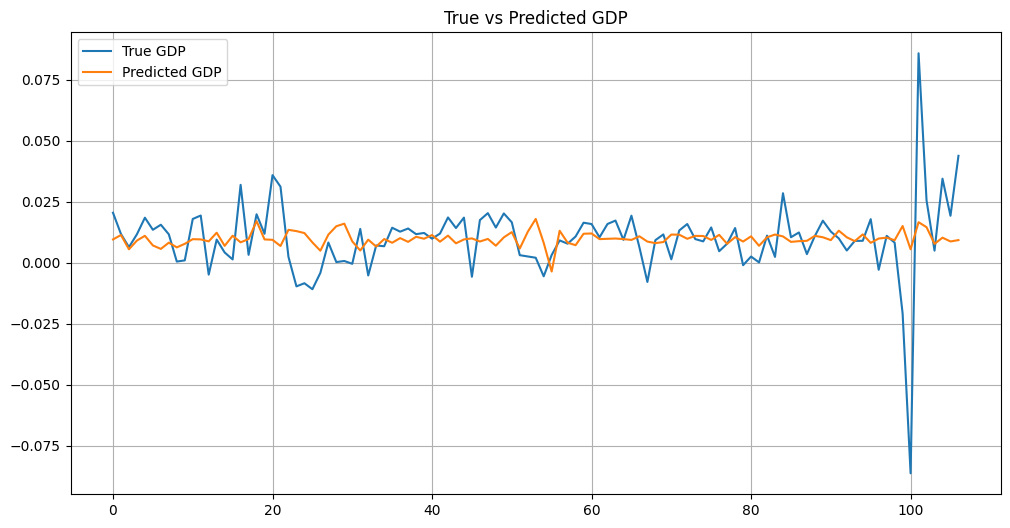

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y, label='True GDP')
plt.plot(y_pred, label='Predicted GDP')
plt.title("True vs Predicted GDP")
plt.legend()
plt.grid(True)
plt.show()


## second attempt

In [ ]:
import pandas as pd
gdp_series = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/y_train_midas.pkl')

In [ ]:
factor_series = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/factor_df_k1_p2_covdiagonal.pkl')

In [ ]:
import eda

In [ ]:
eda.plot_time_series_altair(factor_series, "factor")

alt.Chart(...)

In [ ]:
eda.plot_time_series_altair(gdp_series, "GDP")

alt.Chart(...)

In [ ]:
import models

In [ ]:
X = models.build_high_freq_lags(factor_series, gdp_series.index, 30)

In [ ]:
y = gdp_series.values

In [ ]:
import midas_almon

In [ ]:
X = X.squeeze(axis=2)  # removes the singleton third dimension
print(X.shape)  # should now be (107, 106)

(107, 30)


In [ ]:
# Create the model
model = midas_almon.AlmonMIDASRegressor(degree=2)  # Polynomial of degree 2

# Fit the model
model.fit(y, X)

# Predict (on training data or new test data)
y_pred = model.predict(X)

### predict

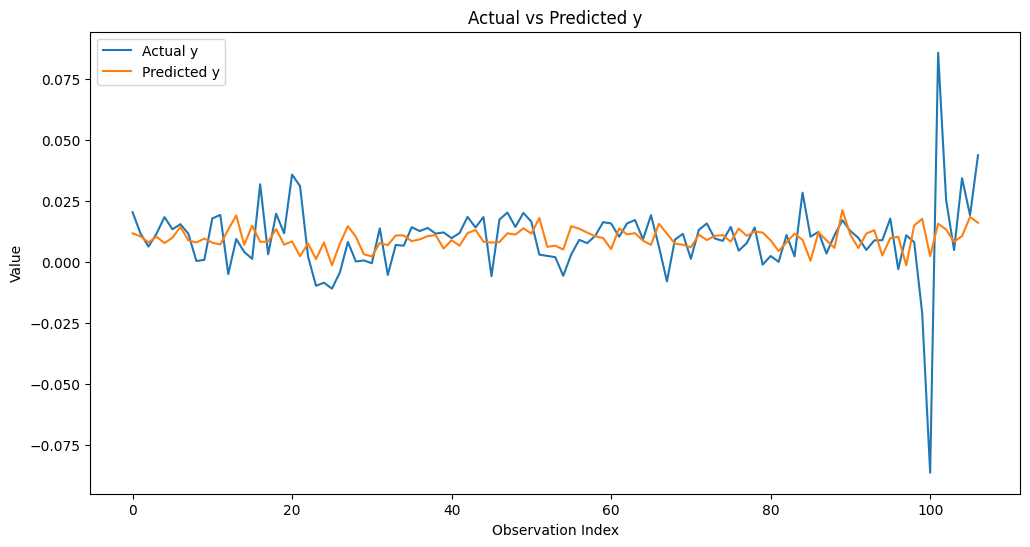

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y, label='Actual y')
plt.plot(y_pred, label='Predicted y')
plt.title('Actual vs Predicted y')
plt.xlabel('Observation Index')
plt.ylabel('Value')
plt.legend()
plt.show()

In [ ]:
import diagnostics

### eval

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# y = true values (from your quarterly series)
# y_pred = predicted values from the model

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

RMSE: 0.0150
MAE:  0.0092
R²:   0.0696


30 days 2 degree

## Montly factor

In [226]:
factor_series = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/factor_df_k4_p2_covdiagonal.pkl')

In [222]:
gdp_series = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/y_train.pkl')['GDP']

In [ ]:
import eda

In [227]:
eda.plot_time_series_altair(factor_series, "4 Factors extracted from DFM")

alt.Chart(...)

In [ ]:
eda.plot_time_series_altair(gdp_series, "GDP")

alt.Chart(...)

### prep

In [ ]:
import models

In [ ]:
import midas_almon

In [223]:
X = models.build_high_freq_lags(factor_series, gdp_series.index, 4)

In [224]:
y = gdp_series.values

In [229]:
print(X.shape)

(107, 4, 4)


In [228]:
X = X.squeeze(axis=2)
print(X.shape)

ValueError: cannot select an axis to squeeze out which has size not equal to one

### train

In [ ]:
# Create the model
model = midas_almon.AlmonMIDASRegressor(degree=2)  # Polynomial of degree 2

# Fit the model
model.fit(y, X)

# Predict (on training data or new test data)
y_pred = model.predict(X)

### predict

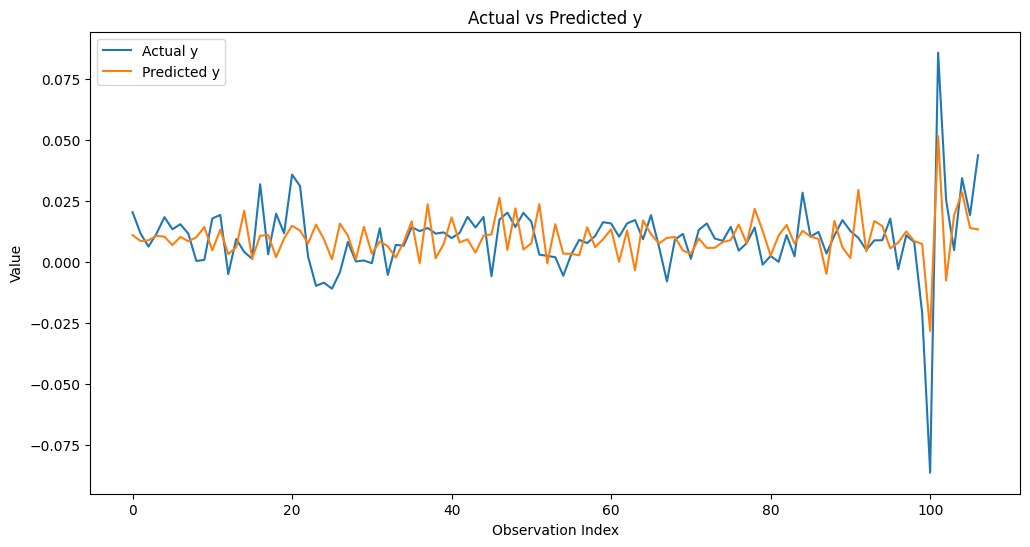

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y, label='Actual y')
plt.plot(y_pred, label='Predicted y')
plt.title('Actual vs Predicted y')
plt.xlabel('Observation Index')
plt.ylabel('Value')
plt.legend()
plt.show()

### eval

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# y = true values (from your quarterly series)
# y_pred = predicted values from the model

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.6f}")

RMSE: 0.012930
MAE:  0.009597
R²:   0.305843


4 month 2 degree

In [214]:
print(0.012930*4)

0.05172


In [215]:
y.describe()

,GDP
count,107.000000
mean,0.009786
std,0.015593
min,-0.086301
25%,0.003140
50%,0.010461
75%,0.015875
max,0.085868


# MIDAS beta

In [231]:
import midas_beta

## prep

In [233]:
y = gdp_series.values

In [238]:
factor_series.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 325 entries, 1995-01-31 to 2022-01-31
Freq: ME
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      325 non-null    float64
 1   f2      325 non-null    float64
 2   f3      325 non-null    float64
 3   f4      325 non-null    float64
dtypes: float64(4)
memory usage: 20.8 KB


In [246]:
factors = factor_series.copy()

In [248]:
gdp_series.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 107 entries, 1995-06-30 to 2021-12-31
Series name: GDP
Non-Null Count  Dtype  
--------------  -----  
107 non-null    float64
dtypes: float64(1)
memory usage: 1.7 KB


## train

In [311]:
import numpy as np
import pandas as pd
from pandas.tseries.offsets import MonthEnd

# GIVEN:
# factors: monthly df with columns ["f1","f2","f3","f4"], index MonthEnd (1995-01-31..)
# y:       quarterly target (log-diff QoQ), index QuarterEnd (1995-06-30..)
# BetaMIDASRegressor: the class from earlier

def build_X_list(factors: pd.DataFrame, q_end: pd.DatetimeIndex, K: int, include_current: bool=True):
    """Return [Xi] where each Xi is (T,K) of monthly lags for factor i, aligned to q_end."""
    jset = range(0, K) if include_current else range(1, K+1)
    X_list = [
        np.column_stack([factors[c].reindex(q_end - MonthEnd(j)).to_numpy() for j in jset])
        for c in factors.columns
    ]
    return X_list

# 1) indices
factors = factors.copy()
factors.index = factors.index.to_period("M").to_timestamp("M")
q_end = gdp_series.index  # quarter-ends already aligned to “real-time”

# 2) build lags (K=3 or 4 מקובל; אם אין את חודש הסגירה בזמן אמת, set include_current=False)
K = 12
X_list = build_X_list(factors, q_end, K, include_current=False)

# 3) חיתוך NaN-ים פעם אחת
valid = gdp_series.notna()
for Xi in X_list:
    valid &= ~np.isnan(Xi).any(axis=1)
q_keep = valid[valid].index
y_fit = gdp_series.reindex(q_keep).to_numpy()
X_list_fit = [Xi[valid.to_numpy(), :] for Xi in X_list]

# 4) התאמה ותחזית
midas = midas_beta.BetaMIDASRegressor(add_intercept=True, ridge=0.0, random_state=0)
midas.fit(y_fit, X_list_fit)
y_hat_in = midas.predict(X_list_fit)

# 5) מדדים פשוטים ביחידות של y (לוג-דיף רבעוני). מהיר ל-tuning.
rmse_q = float(np.sqrt(np.mean((y_hat_in - y_fit)**2)))
mae_q  = float(np.mean(np.abs(y_hat_in - y_fit)))
print({"RMSE_logdiff": rmse_q, "MAE_logdiff": mae_q, "K": K})


{'RMSE_logdiff': 0.009448248348424308, 'MAE_logdiff': 0.007209069621729612, 'K': 12}


## eval

In [313]:
y_pred = midas.predict(X_list_fit)

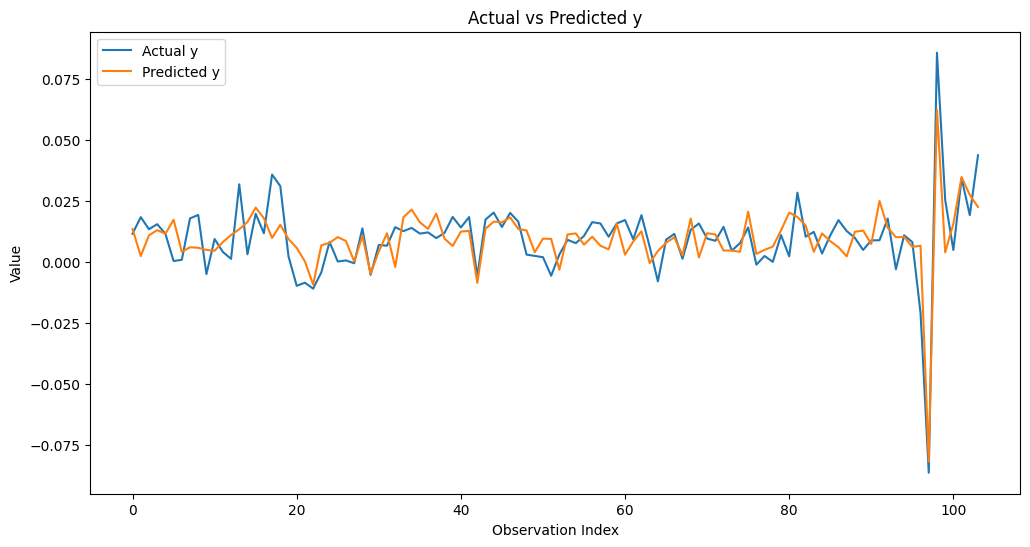

In [314]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_fit, label='Actual y')
plt.plot(y_pred, label='Predicted y')
plt.title('Actual vs Predicted y')
plt.xlabel('Observation Index')
plt.ylabel('Value')
plt.legend()
plt.show()

K=12

In [289]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# y = true values (from your quarterly series)
# y_pred = predicted values from the model

mse = mean_squared_error(y_fit, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_fit, y_pred)
r2 = r2_score(y_fit, y_pred)

print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.6f}")

RMSE: 0.009418
MAE:  0.007138
R²:   0.636962


In [315]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# y = true values (from your quarterly series)
# y_pred = predicted values from the model

mse = mean_squared_error(y_fit, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_fit, y_pred)
r2 = r2_score(y_fit, y_pred)

print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.6f}")

RMSE: 0.009448
MAE:  0.007209
R²:   0.637926


K=9

In [300]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# y = true values (from your quarterly series)
# y_pred = predicted values from the model

mse = mean_squared_error(y_fit, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_fit, y_pred)
r2 = r2_score(y_fit, y_pred)

print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.6f}")

RMSE: 0.009250
MAE:  0.007143
R²:   0.646464


In [310]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# y = true values (from your quarterly series)
# y_pred = predicted values from the model

mse = mean_squared_error(y_fit, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_fit, y_pred)
r2 = r2_score(y_fit, y_pred)

print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.6f}")

RMSE: 0.009630
MAE:  0.007332
R²:   0.620372
